In [5]:
#Scaler assignment for Porters: Predicting delivery time

In [ ]:
#Here I used a 3 dense layer ANN for regression and tried various methods to reduce the losses
#I found that the MSE loss of an ANN over 20 iterations is comparable to using a GBM or a RandomForestRegressor

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import sklearn

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
import datetime
from datetime import datetime

In [10]:
data=pd.read_csv("D:\\scaler\\porter_nn_dataset_scaler.csv")

In [11]:
data.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [12]:
data.shape

(175777, 14)

In [13]:
data.columns

Index(['market_id', 'created_at', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration'],
      dtype='object')

In [14]:
data.dtypes

market_id                                       float64
created_at                                       object
actual_delivery_time                             object
store_primary_category                            int64
order_protocol                                  float64
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_store_to_consumer_driving_duration    float64
dtype: object

In [15]:
data.isnull().sum()

market_id                                       0
created_at                                      0
actual_delivery_time                            0
store_primary_category                          0
order_protocol                                  0
total_items                                     0
subtotal                                        0
num_distinct_items                              0
min_item_price                                  0
max_item_price                                  0
total_onshift_dashers                           0
total_busy_dashers                              0
total_outstanding_orders                        0
estimated_store_to_consumer_driving_duration    0
dtype: int64

In [16]:
pd.to_datetime(data['created_at']).dt.date

0         2015-02-06
1         2015-02-10
2         2015-02-16
3         2015-02-12
4         2015-01-27
             ...    
175772    2015-02-17
175773    2015-02-13
175774    2015-01-24
175775    2015-02-01
175776    2015-02-08
Name: created_at, Length: 175777, dtype: object

In [17]:
pd.to_datetime(data['actual_delivery_time']).dt.date

0         2015-02-06
1         2015-02-10
2         2015-02-16
3         2015-02-12
4         2015-01-27
             ...    
175772    2015-02-17
175773    2015-02-13
175774    2015-01-24
175775    2015-02-01
175776    2015-02-08
Name: actual_delivery_time, Length: 175777, dtype: object

In [18]:
data['days to deliver']=pd.to_datetime(data['actual_delivery_time'])-pd.to_datetime(data['created_at'])

In [19]:
data['min to deliver']=data['days to deliver'].apply(pd.to_timedelta).dt.components['minutes']

In [20]:
data.drop('days to deliver', axis=1, inplace=True)

In [21]:
#data['days to deliver'].apply(pd.to_timedelta).dt.components['seconds']

In [22]:
data.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,min to deliver
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46


In [23]:
data['time wasted']=((data['min to deliver']*60)-data['estimated_store_to_consumer_driving_duration'])/60

In [24]:
data.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,min to deliver,time wasted
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47,32.650000
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44,32.500000
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55,50.183333
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59,45.750000
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46,42.583333


In [25]:
data['store_primary_category'].value_counts()

store_primary_category
4     18183
55    15745
46    15586
13     9915
58     8995
      ...  
1        10
43        9
8         2
21        1
3         1
Name: count, Length: 73, dtype: int64

In [26]:
data['order_protocol'].value_counts()

order_protocol
1.0    48404
3.0    47125
5.0    41415
2.0    20890
4.0    17246
6.0      678
7.0       19
Name: count, dtype: int64

In [27]:
data['num_distinct_items'].value_counts()

num_distinct_items
2     52718
1     43993
3     37435
4     20780
5     10537
6      5065
7      2611
8      1252
9       650
10      351
11      195
12       88
13       50
14       27
15       12
16        6
18        3
17        2
20        1
19        1
Name: count, dtype: int64

<Axes: xlabel='num_distinct_items', ylabel='time wasted'>

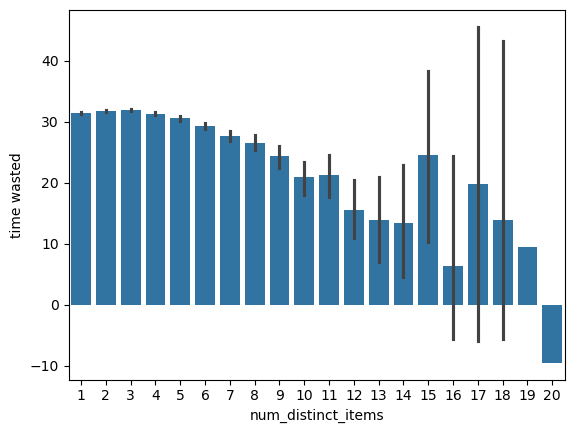

In [28]:
sns.barplot(data=data, x='num_distinct_items', y='time wasted')

In [29]:
#for large batch sizes, our predictability on time wasted is very poor.

In [30]:
data['total_idle_dashers']=data['total_onshift_dashers']-data['total_busy_dashers']

<Axes: xlabel='total_outstanding_orders', ylabel='min to deliver'>

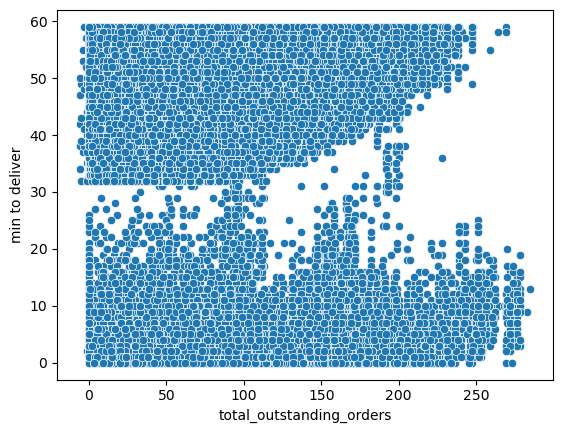

In [31]:
sns.scatterplot(data=data, x='total_outstanding_orders', y='min to deliver')

In [32]:
data.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,min to deliver,time wasted,total_idle_dashers
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47,32.650000,19.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44,32.500000,-1.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55,50.183333,2.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59,45.750000,-1.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46,42.583333,0.0


In [33]:
data.columns

Index(['market_id', 'created_at', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration', 'min to deliver',
       'time wasted', 'total_idle_dashers'],
      dtype='object')

<Axes: xlabel='total_idle_dashers', ylabel='time wasted'>

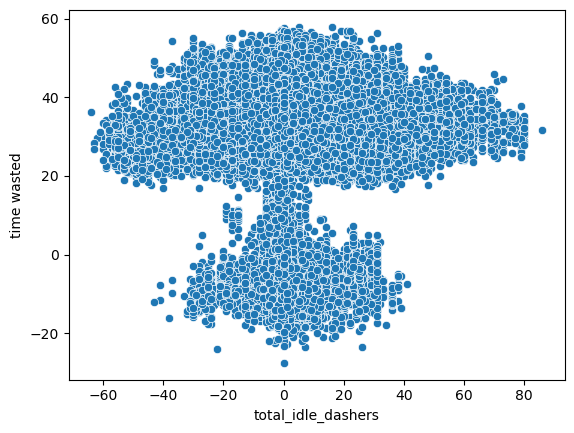

In [34]:
sns.scatterplot(data=data, x='total_idle_dashers', y='time wasted')

In [35]:
data['per_idle_dashers']=data['total_idle_dashers']/data['total_onshift_dashers']

In [36]:
data['per_idle_dashers'].value_counts().sort_index(ascending=True)

per_idle_dashers
-inf     35
-30.0     1
-29.0     1
-28.0     1
-22.0     2
         ..
 7.0      2
 8.0      1
 10.0     1
 14.0     1
 inf      3
Name: count, Length: 4011, dtype: int64

In [37]:
temp_new=data.drop(data[data['total_onshift_dashers']<0].index)

In [38]:
temp_new=temp_new[temp_new['total_idle_dashers']>=0]

In [39]:
temp_new

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,min to deliver,time wasted,total_idle_dashers,per_idle_dashers
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47,32.650000,19.0,0.575758
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55,50.183333,2.0,0.250000
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46,42.583333,0.0,0.000000
5,1.0,2015-02-06 00:42:42,2015-02-06 01:38:42,38,1.0,3,4475,3,925,1825,4.0,1.0,1.0,542.0,56,46.966667,3.0,0.750000
6,1.0,2015-02-08 02:04:17,2015-02-08 03:07:17,38,1.0,3,4375,3,1325,1625,6.0,4.0,3.0,789.0,3,-10.150000,2.0,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175770,2.0,2015-02-18 02:16:04,2015-02-18 02:59:04,36,3.0,3,2352,3,499,685,49.0,49.0,65.0,560.0,43,33.666667,0.0,0.000000
175772,1.0,2015-02-17 00:19:41,2015-02-17 01:02:41,28,4.0,3,1389,3,345,649,17.0,17.0,23.0,331.0,43,37.483333,0.0,0.000000
175773,1.0,2015-02-13 00:01:59,2015-02-13 01:03:59,28,4.0,6,3010,4,405,825,12.0,11.0,14.0,915.0,2,-13.250000,1.0,0.083333
175775,1.0,2015-02-01 18:18:15,2015-02-01 19:03:15,58,1.0,1,1175,1,535,535,7.0,7.0,12.0,384.0,45,38.600000,0.0,0.000000


<Axes: >

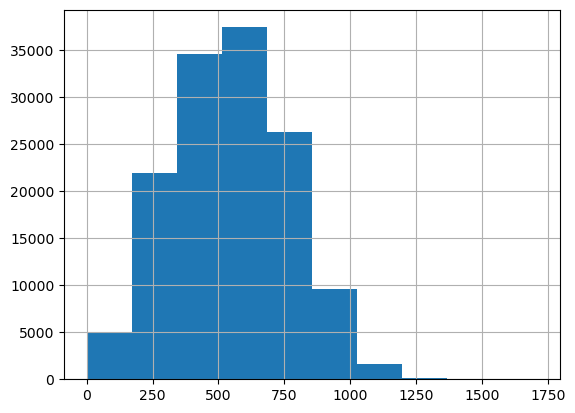

In [40]:
temp_new['estimated_store_to_consumer_driving_duration'].hist()

In [41]:
temp_new['total_outstanding_orders'].value_counts()

total_outstanding_orders
 0.0      3983
 6.0      2229
 9.0      2171
 4.0      2144
 8.0      2143
          ... 
-4.0         1
 283.0       1
 245.0       1
 273.0       1
 249.0       1
Name: count, Length: 277, dtype: int64

<Axes: >

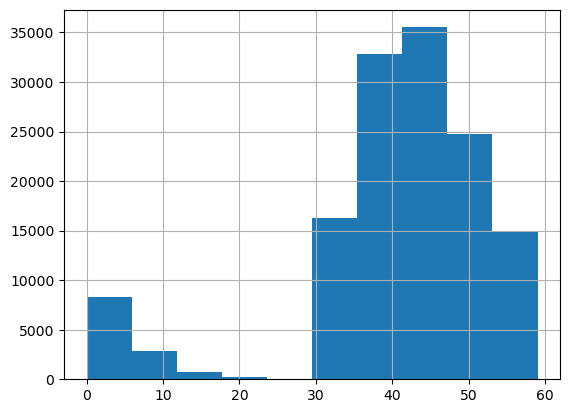

In [42]:
temp_new['min to deliver'].hist()

<Axes: >

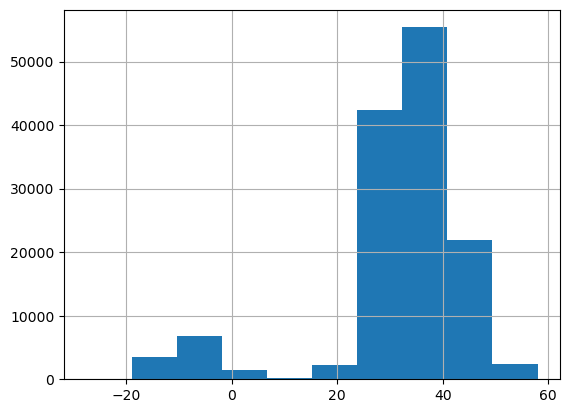

In [43]:
temp_new['time wasted'].hist()

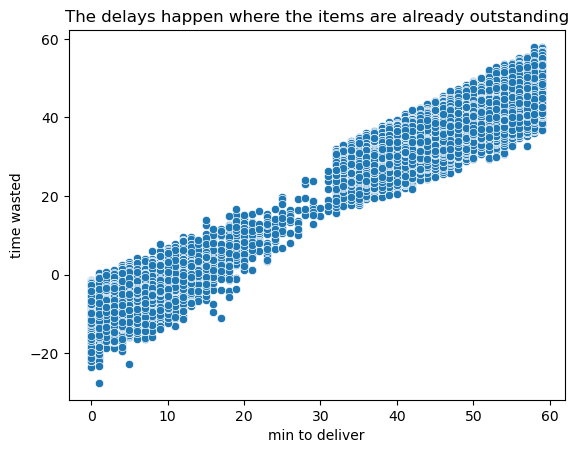

In [44]:
sns.scatterplot(data=temp_new, x='min to deliver', y='time wasted')
plt.title('The delays happen where the items are already outstanding')
plt.show()

<Axes: xlabel='order_protocol', ylabel='min to deliver'>

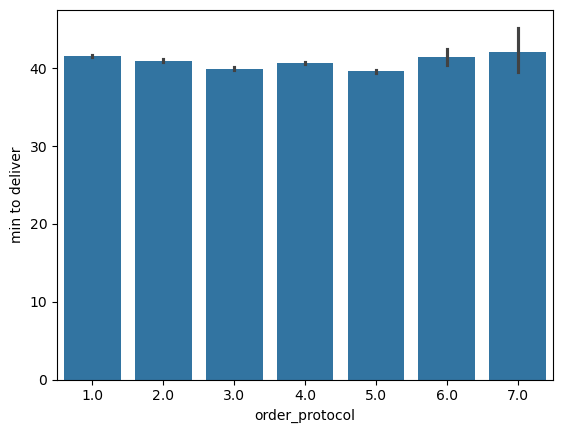

In [45]:
sns.barplot(data=temp_new, x='order_protocol', y='min to deliver', )

<Axes: xlabel='total_outstanding_orders', ylabel='min to deliver'>

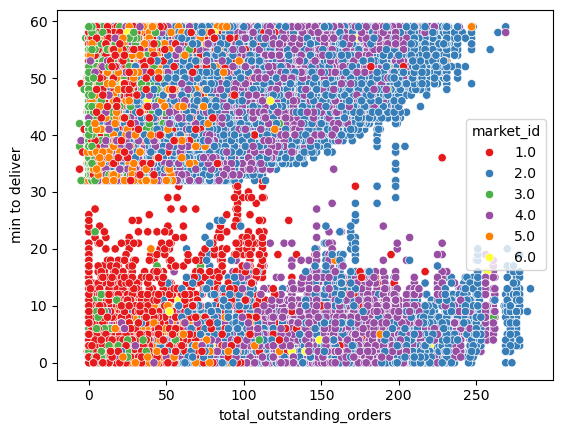

In [46]:
sns.scatterplot(data=temp_new, x='total_outstanding_orders', y='min to deliver', hue='market_id', palette='Set1')

In [47]:
#temp_new.corrwith(temp_new['min to deliver'])

In [48]:
temp_new['min to deliver'].unique()

array([47, 55, 46, 56,  3, 37, 45,  7, 43, 42, 44, 40, 59,  4, 34, 32, 48,
       38, 52, 57, 41, 36, 39, 35, 53, 50, 49, 51,  1,  2,  5,  9,  8, 58,
        6, 33,  0, 11, 54, 10, 25, 16, 14, 12, 13, 31, 15, 20, 18, 19, 17,
       21, 23, 22, 28, 24, 29, 27, 26, 30])

In [49]:
temp_new.columns

Index(['market_id', 'created_at', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration', 'min to deliver',
       'time wasted', 'total_idle_dashers', 'per_idle_dashers'],
      dtype='object')

In [50]:
temp_new[['store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items','min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'estimated_store_to_consumer_driving_duration',
       'total_idle_dashers', 'per_idle_dashers']].corrwith(temp_new['min to deliver'])

C:\Users\ASUS\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\ASUS\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


store_primary_category                         -0.022086
order_protocol                                 -0.051866
total_items                                    -0.042177
subtotal                                       -0.078484
num_distinct_items                             -0.051640
min_item_price                                  0.005673
max_item_price                                 -0.029930
total_onshift_dashers                          -0.087975
total_busy_dashers                             -0.099571
estimated_store_to_consumer_driving_duration    0.020211
total_idle_dashers                             -0.001968
per_idle_dashers                                     NaN
dtype: float64

<Axes: xlabel='order_protocol', ylabel='min to deliver'>

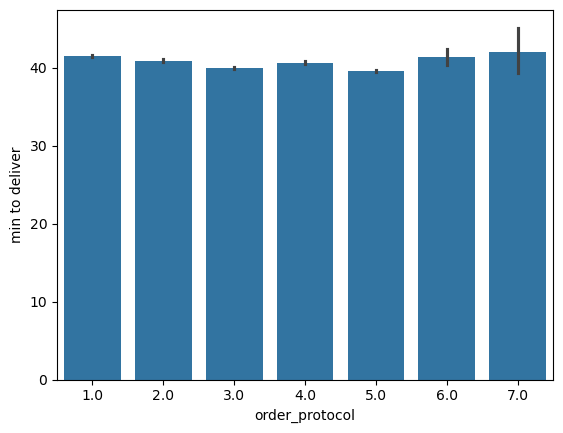

In [51]:
sns.barplot(data=temp_new, x='order_protocol',y='min to deliver')

In [52]:
sort_order_for_store_cat=temp_new.groupby('store_primary_category')['min to deliver'].mean().sort_values(ascending=False)

<Axes: xlabel='store_primary_category'>

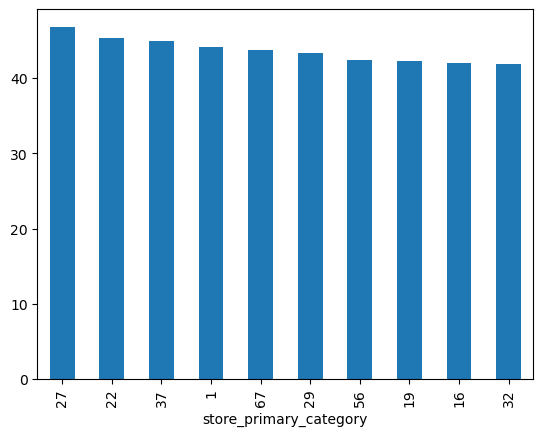

In [53]:
sort_order_for_store_cat[:10].plot(kind='bar')

In [54]:
total_os_by_store_cat=temp_new.groupby('store_primary_category')['total_outstanding_orders'].mean().sort_values(ascending=False)

<Axes: xlabel='store_primary_category'>

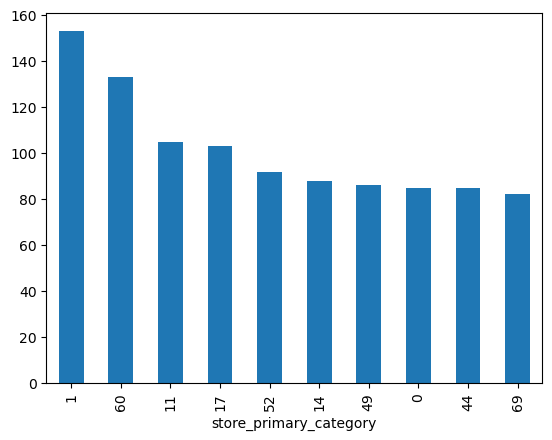

In [55]:
total_os_by_store_cat[:10].plot(kind='bar')

<Axes: xlabel='market_id'>

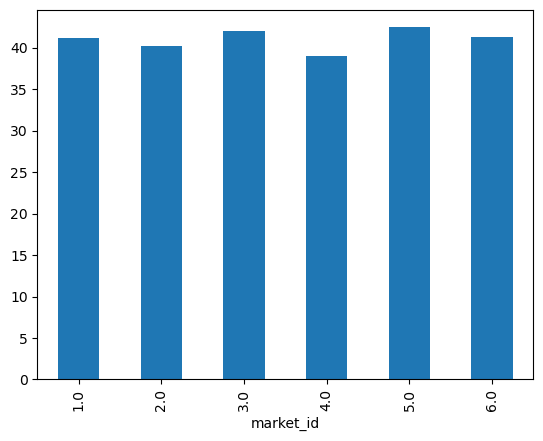

In [56]:
temp_new.groupby('market_id')['min to deliver'].mean().plot(kind='bar')

<Axes: xlabel='market_id'>

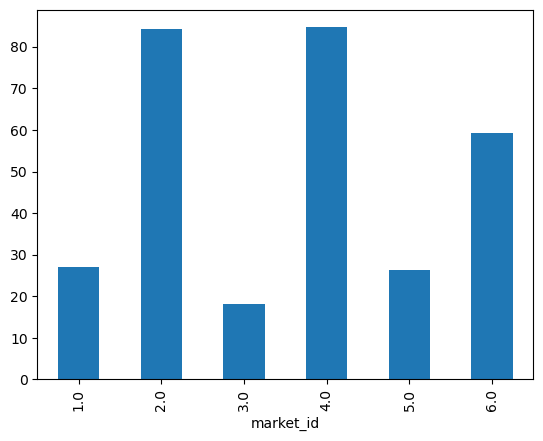

In [57]:
temp_new.groupby('market_id')['total_outstanding_orders'].mean().plot(kind='bar')

In [58]:
temp_new[['store_primary_category', 'order_protocol','total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'total_idle_dashers', 'per_idle_dashers']].corrwith(temp_new['min to deliver'])

C:\Users\ASUS\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\ASUS\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


store_primary_category     -0.022086
order_protocol             -0.051866
total_items                -0.042177
subtotal                   -0.078484
num_distinct_items         -0.051640
min_item_price              0.005673
max_item_price             -0.029930
total_onshift_dashers      -0.087975
total_busy_dashers         -0.099571
total_outstanding_orders   -0.143904
total_idle_dashers         -0.001968
per_idle_dashers                 NaN
dtype: float64

<Axes: >

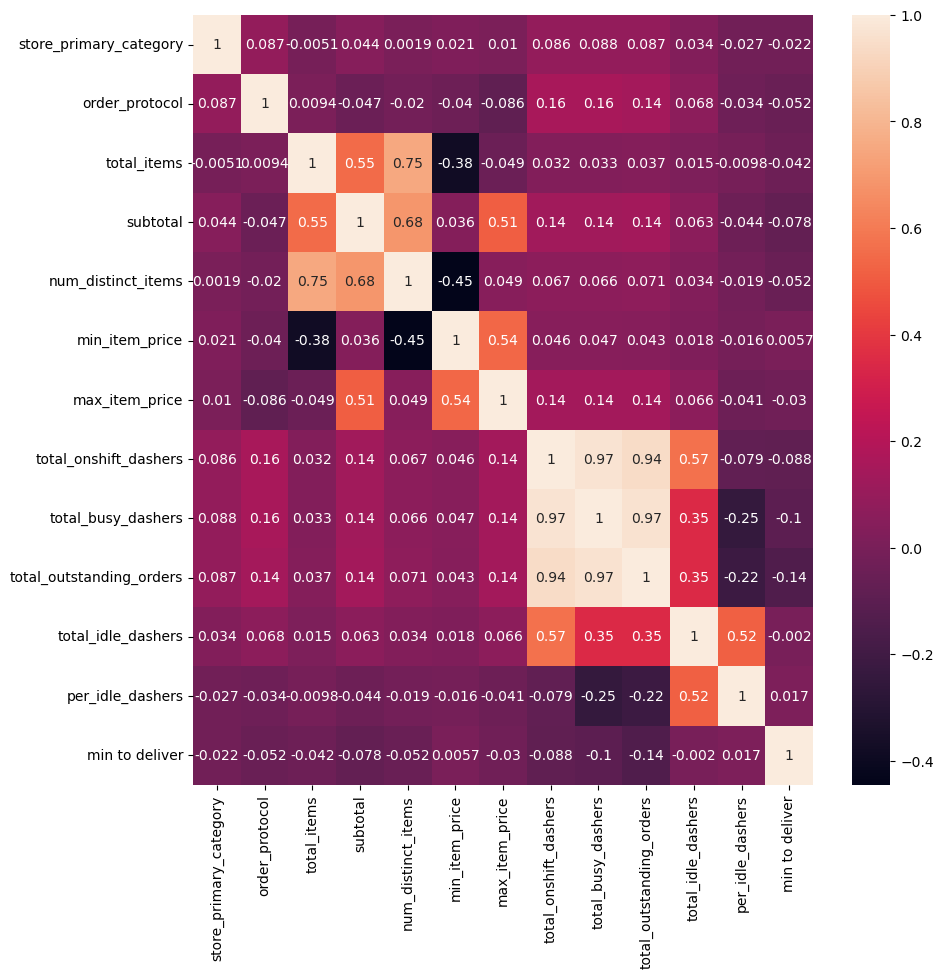

In [59]:
plt.figure(figsize=(10,10))
sns.heatmap(temp_new[['store_primary_category', 'order_protocol','total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'total_idle_dashers', 'per_idle_dashers','min to deliver']].corr(), annot=True)

In [60]:
import statsmodels

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [62]:
from statsmodels.tools.tools import add_constant

In [63]:
temp_2=temp_new[['store_primary_category', 'order_protocol','total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_outstanding_orders',
       'total_idle_dashers']]

In [64]:
temp_2=add_constant(temp_2)

In [65]:
temp_2=temp_2.astype(float)

In [66]:
temp_2

,const,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_outstanding_orders,total_idle_dashers
0,1.0,4.0,1.0,4.0,3441.0,4.0,557.0,1239.0,21.0,19.0
2,1.0,36.0,3.0,4.0,4771.0,3.0,820.0,1604.0,18.0,2.0
4,1.0,38.0,1.0,2.0,3620.0,2.0,1425.0,2195.0,7.0,0.0
5,1.0,38.0,1.0,3.0,4475.0,3.0,925.0,1825.0,1.0,3.0
6,1.0,38.0,1.0,3.0,4375.0,3.0,1325.0,1625.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...
175770,1.0,36.0,3.0,3.0,2352.0,3.0,499.0,685.0,65.0,0.0
175772,1.0,28.0,4.0,3.0,1389.0,3.0,345.0,649.0,23.0,0.0
175773,1.0,28.0,4.0,6.0,3010.0,4.0,405.0,825.0,14.0,1.0
175775,1.0,58.0,1.0,1.0,1175.0,1.0,535.0,535.0,12.0,0.0


In [67]:
vif_df=pd.DataFrame()

In [68]:
vif_df['Features']=temp_2.columns

In [69]:
vif_df

,Features
0,const
1,store_primary_category
2,order_protocol
3,total_items
4,subtotal
5,num_distinct_items
6,min_item_price
7,max_item_price
8,total_outstanding_orders
9,total_idle_dashers


In [70]:
temp_2.shape

(136487, 10)

In [71]:
temp_2.dtypes

const                       float64
store_primary_category      float64
order_protocol              float64
total_items                 float64
subtotal                    float64
num_distinct_items          float64
min_item_price              float64
max_item_price              float64
total_outstanding_orders    float64
total_idle_dashers          float64
dtype: object

In [72]:
#Multi collinearity based on the heatmap and vif
#All these have no multicollinearity now

In [73]:
vif_df['vif']=[vif(temp_2.values, i) for i in range(temp_2.shape[1])]

In [74]:
vif_df

,Features,vif
0,const,18.897140
1,store_primary_category,1.018281
2,order_protocol,1.041508
3,total_items,2.429048
4,subtotal,3.614582
5,num_distinct_items,4.029353
6,min_item_price,2.135188
7,max_item_price,2.285299
8,total_outstanding_orders,1.192991
9,total_idle_dashers,1.140663


In [75]:
#The multi collinearity between the features so I can keep only a few features

In [76]:
#so if I use only total_outstanding dashers I should probably get the same result because these are highly correlated

In [77]:
sort_order_for_num_distinct_items=temp_new.groupby('store_primary_category')['num_distinct_items'].mean().sort_values(ascending=False)

<Axes: xlabel='store_primary_category'>

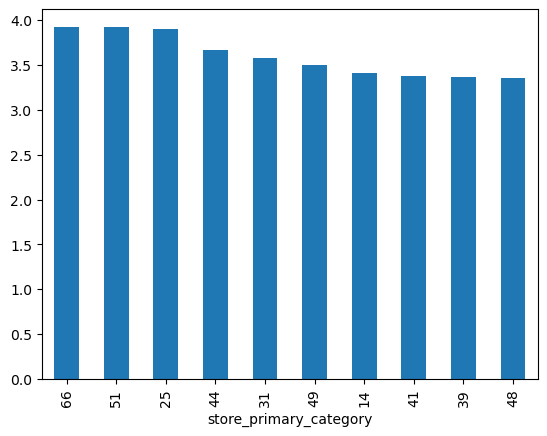

In [78]:
sort_order_for_num_distinct_items[:10].plot(kind='bar')

In [79]:
sort_order_for_os_orders=temp_new.groupby('store_primary_category')['total_outstanding_orders'].mean().sort_values(ascending=False)

<Axes: xlabel='store_primary_category'>

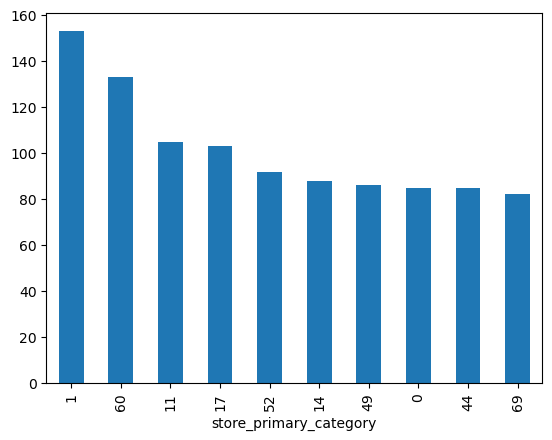

In [80]:
sort_order_for_os_orders[:10].plot(kind='bar')

<Axes: xlabel='subtotal', ylabel='min to deliver'>

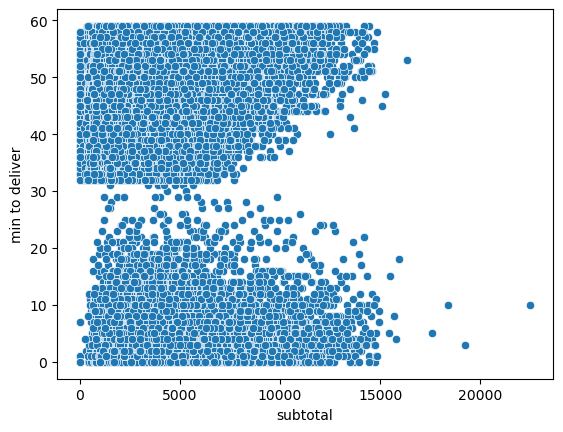

In [81]:
sns.scatterplot(data=temp_new, x='subtotal', y='min to deliver')

In [82]:
temp_new.shape

(136487, 18)

In [83]:
#pip install tensorflow

In [84]:
import tensorflow as tf

In [85]:
from tensorflow import keras

In [86]:
from keras.models import Sequential, Model

In [87]:
from keras.layers import Dense, Input

In [88]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

In [89]:
x=temp_2.drop(['const','min_item_price','total_idle_dashers'], axis=1)
y=temp_new['min to deliver']

In [90]:
x.columns

Index(['store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'max_item_price', 'total_outstanding_orders'],
      dtype='object')

In [91]:
x.shape

(136487, 7)

In [92]:
from statsmodels.api import OLS

In [93]:
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=10)

In [94]:
model=OLS(ytrain, xtrain).fit()

In [95]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         min to deliver   R-squared (uncentered):                   0.842
Model:                            OLS   Adj. R-squared (uncentered):              0.842
Method:                 Least Squares   F-statistic:                          8.283e+04
Date:                Tue, 10 Mar 2026   Prob (F-statistic):                        0.00
Time:                        23:37:41   Log-Likelihood:                     -4.6409e+05
No. Observations:              109189   AIC:                                  9.282e+05
Df Residuals:                  109182   BIC:                                  9.283e+05
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
store_primary_category       0.2068      0.002     90.182      0.000       0.202       0.211
order_protocol               3.1925      0.031    104.481      0.000       3.133       3.252
total_items                  0.6215      0.028     22.337      0.000       0.567       0.676
subtotal                    -0.0042   4.91e-05    -85.158      0.000      -0.004      -0.004
num_distinct_items           4.5207      0.052     87.166      0.000       4.419       4.622
max_item_price               0.0166      0.000    165.196      0.000       0.016       0.017
total_outstanding_orders    -0.0152      0.001    -15.692      0.000      -0.017      -0.013
==============================================================================
Omnibus:                    24035.606   Durbin-Watson:                   1.956
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            60406.400
Skew:                          -1.210   Prob(JB):                         0.00
Kurtosis:                       5.723   Cond. No.                     3.71e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 3.71e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [96]:
ypred_linreg=model.predict(xtest)

In [97]:
from sklearn.metrics import mean_squared_error

In [98]:
print(mean_squared_error(ytest, ypred_linreg)) #This is with an older statistical model-this is the minimum we should achieve

289.44720739022017


In [ ]:
#Trying with a random forest model since the decision boundary is non linear

In [99]:
from sklearn.ensemble import RandomForestRegressor

In [100]:
model_rf=RandomForestRegressor()

In [101]:
model_rf.fit(xtrain, ytrain)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
ypred_rf=model_rf.predict(xtest)

In [103]:
print(mean_squared_error(ytest, ypred_rf))

172.4107449319205


In [ ]:
#This is much better than a simple linear regression

In [95]:
callback=ModelCheckpoint(filepath='D:\\scaler\\model_1.keras', monitor='val_loss',save_best_only=True)

In [96]:
nn_model=Sequential()

In [97]:
nn_model.add(Dense(256,input_shape=(7,)))

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
nn_model.add(Dense(128, activation='relu'))

In [99]:
nn_model.add(Dense(64, activation='relu'))

In [100]:
nn_model.add(Dense(32,activation='relu'))

In [101]:
nn_model.add(Dense(16, activation='relu'))

In [102]:
nn_model.add(Dense(8, activation='relu'))

In [103]:
nn_model.add(Dense(1, activation='linear'))

In [104]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,953 (179.50 KB)

 Trainable params: 45,953 (179.50 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
from keras.optimizers import Adam, SGD

In [106]:
optimizer=Adam(learning_rate=0.001)

In [107]:
nn_model.compile(optimizer=optimizer,loss='mean_squared_error')

In [108]:
x.shape

(136487, 7)

In [109]:
y.shape

(136487,)

In [110]:
nn_model.fit(xtrain, ytrain, validation_split=0.2, epochs=20, callbacks=callback)

Epoch 1/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 370.0484 - val_loss: 250.5218
Epoch 2/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 250.9044 - val_loss: 206.8371
Epoch 3/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 193.5581 - val_loss: 181.3610
Epoch 4/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 180.7474 - val_loss: 176.3613
Epoch 5/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 176.6040 - val_loss: 177.0927
Epoch 6/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 173.1944 - val_loss: 177.0982
Epoch 7/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 174.5428 - val_loss: 177.5072
Epoch 8/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 173.3523 - val_loss: 177.6809
Epoch 9/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 173.3272 - val_loss: 176.9569
Epoch 10/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 173.4106 - val_loss: 180.5184
Epoch 11/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 173.7

In [111]:
nn_model.load_weights('D:\\scaler\\model_1.keras')

In [112]:
nn_model.compile(optimizer=optimizer, loss='mean_squared_error')

In [113]:
ypred=nn_model.predict(xtest)

854/854 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [114]:
ypred.shape

(27298, 1)

In [115]:
ytest=np.array(ytest).reshape(-1,1)

In [116]:
ytest.shape

(27298, 1)

In [117]:
mse=np.mean((ytest-ypred)**2)

In [118]:
print("MSE with the best val_loss:", mse)

MSE with the best val_loss: 176.70888665933265


In [119]:
#nn_model.evaluate(xtest, ytest)

In [120]:
#After initial scaling

In [121]:
callback_sc=ModelCheckpoint(filepath='D:\\scaler\\model_2.keras', monitor='val_loss', save_best_only=True)

In [114]:
from sklearn.preprocessing import StandardScaler

In [115]:
sc=StandardScaler()

In [116]:
xtrain_sc=sc.fit_transform(xtrain)
xtest_sc=sc.transform(xtest)

In [125]:
nn2=Sequential()

In [126]:
nn2.add(Dense(256, input_shape=(7,)))

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [127]:
nn2.add(Dense(128, activation='relu'))

In [128]:
nn2.add(Dense(64, activation='relu'))

In [129]:
nn2.add(Dense(32, activation='relu'))

In [130]:
nn2.add(Dense(16, activation='relu'))

In [131]:
nn2.add(Dense(8, activation='relu'))

In [132]:
nn2.add(Dense(1, activation='linear'))

In [133]:
optimizer_2=Adam(learning_rate=0.001)

In [134]:
nn2.compile(optimizer=optimizer_2, loss='mean_squared_error')

In [135]:
nn2.fit(xtrain_sc, ytrain, validation_split=.2, epochs=20, callbacks=callback_sc)

Epoch 1/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 191.7348 - val_loss: 167.0069
Epoch 2/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 166.0632 - val_loss: 167.8660
Epoch 3/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 164.7080 - val_loss: 166.5854
Epoch 4/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 164.1926 - val_loss: 165.3268
Epoch 5/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 163.0548 - val_loss: 168.3335
Epoch 6/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 162.5553 - val_loss: 163.3264
Epoch 7/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 162.2007 - val_loss: 168.5493
Epoch 8/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 162.1158 - val_loss: 164.8769
Epoch 9/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 161.7113 - val_loss: 167.6698
Epoch 10/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 161.3855 - val_loss: 163.6031
Epoch 11/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 161.5

In [136]:
nn2.load_weights('D:\\scaler\\model_2.keras')

In [137]:
ypred_2=nn2.predict(xtest_sc)

854/854 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [138]:
mse_2=np.mean((ytest-ypred_2)**2)

In [139]:
print("MSE after scaling", mse_2)

MSE after scaling 162.74340191865355


In [140]:
from keras.layers import BatchNormalization, Dropout

In [141]:
callback_3=ModelCheckpoint(filepath='D:\\scaler\\model_3.keras', monitor='val_loss',save_best_only=True)

In [142]:
nn_3=Sequential()

In [143]:
nn_3.add(Dense(256, input_shape=(7,)))

In [144]:
nn_3.add(Dense(128, activation='relu'))

In [145]:
nn_3.add(Dense(64, activation='relu'))

In [146]:
nn_3.add(BatchNormalization())

In [147]:
nn_3.add(Dense(32, activation='relu'))

In [148]:
nn_3.add(Dense(16, activation='relu'))
nn_3.add(BatchNormalization())
nn_3.add(Dense(8, activation='relu'))

In [149]:
nn_3.add(Dense(1, activation='linear'))

In [150]:
opt_3=Adam(learning_rate=.001)

In [151]:
nn_3.compile(optimizer=opt_3, loss='mean_squared_error')

In [152]:
nn_3.fit(xtrain_sc, ytrain, validation_split=0.2, epochs=20, callbacks=callback_3)

Epoch 1/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 315.2328 - val_loss: 167.5290
Epoch 2/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 168.4349 - val_loss: 166.7077
Epoch 3/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 164.8321 - val_loss: 165.1224
Epoch 4/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 164.0147 - val_loss: 165.8382
Epoch 5/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 162.8994 - val_loss: 165.1190
Epoch 6/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 162.2524 - val_loss: 164.8742
Epoch 7/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 161.8715 - val_loss: 165.0801
Epoch 8/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 161.3525 - val_loss: 164.2746
Epoch 9/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 161.4986 - val_loss: 168.0191
Epoch 10/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 161.1086 - val_loss: 163.6953
Epoch 11/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 160.7

In [153]:
nn_3.load_weights('D:\\scaler\\model_3.keras')

In [154]:
ypred_3=nn_3.predict(xtest_sc)

854/854 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [155]:
mse_3=np.mean((ytest-ypred_3)**2)

In [156]:
print("MSE after adding one batch normalization to a hidden layer", mse_3)

MSE after adding one batch normalization to a hidden layer 162.59026544825065


In [157]:
# After batch normalization or scaling, we see that the model converges faster.
#with batch normalization the loss reduced very quickly in the first few iterations

In [158]:
nn_4=Sequential()
nn_4.add(Dense(256, input_shape=(7,)))

In [159]:
nn_4.add(Dense(128, activation='relu'))

In [160]:
nn_4.add(Dropout(.2))

In [161]:
nn_4.add(Dense(64, activation='relu'))

In [162]:
nn_4.add(Dense(32, activation='relu'))

In [163]:
nn_4.add(Dropout(.2))

In [164]:
nn_4.add(Dense(16, activation='relu'))

In [165]:
nn_4.add(Dense(8, activation='relu'))

In [166]:
nn_4.add(Dense(1, activation='linear'))

In [167]:
opt_4=Adam(learning_rate=0.001)

In [168]:
callback_4=ModelCheckpoint(filepath='D:\\scaler\\model_4.keras', monitor='val_loss', save_best_only=True)

In [169]:
nn_4.compile(optimizer=opt_4, loss='mean_squared_error')

In [170]:
nn_4.fit(xtrain_sc, ytrain, callbacks=callback_4, validation_split=0.2,epochs=20)

Epoch 1/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 206.3338 - val_loss: 227.8345
Epoch 2/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 173.0324 - val_loss: 231.7791
Epoch 3/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 170.9483 - val_loss: 220.8052
Epoch 4/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 168.7648 - val_loss: 240.7162
Epoch 5/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 168.3736 - val_loss: 232.8341
Epoch 6/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 167.6333 - val_loss: 184.2596
Epoch 7/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 167.1545 - val_loss: 218.5674
Epoch 8/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 166.1125 - val_loss: 208.4967
Epoch 9/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 165.6188 - val_loss: 189.5890
Epoch 10/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 165.1678 - val_loss: 192.8786
Epoch 11/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 164.7

In [171]:
#So using dropout without batch normalization causes the values to fluctuate wildly and not converge, loss is increasing
#Also since there is no evidence of overfitting, I do not believe the dropout layer or regularization is needed here, I just tried for checking how it converges.

In [172]:
nn_4.load_weights('D:\\scaler\\model_4.keras')

In [173]:
nn_4.evaluate(xtest_sc, ytest) #This is mse with dropout

854/854 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 165.2931


165.2931365966797

In [174]:
#Increasing the learning rate parameter leads to faster convergence

In [175]:
opt_5=Adam(learning_rate=0.01)

In [176]:
callback_5=ModelCheckpoint(filepath='D:\\scaler\\model_5.keras', monitor='val_loss', save_best_only=True)

In [177]:
nn_5=Sequential()

In [178]:
nn_5.add(Dense(256, input_shape=(7,)))

In [179]:
nn_5.add(Dense(128, activation='relu'))

In [180]:
nn_5.add(Dense(64, activation='relu'))

In [181]:
nn_5.add(BatchNormalization())

In [182]:
nn_5.add(Dense(32, activation='relu'))
nn_5.add(Dense(16, activation='relu'))

In [183]:
nn_5.add(BatchNormalization())

In [184]:
nn_5.add(Dense(8, activation='relu'))

In [185]:
nn_5.add(Dense(1, activation='linear'))

In [186]:
nn_5.compile(optimizer=opt_5, loss='mean_squared_error')

In [187]:
nn_5.fit(xtrain_sc, ytrain, epochs=20, validation_split=0.2, callbacks=callback_5)

Epoch 1/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 186.7001 - val_loss: 166.9811
Epoch 2/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 165.0461 - val_loss: 167.7118
Epoch 3/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 164.4541 - val_loss: 217.8621
Epoch 4/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 163.6906 - val_loss: 167.2861
Epoch 5/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 162.9881 - val_loss: 164.9528
Epoch 6/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 162.6006 - val_loss: 164.0129
Epoch 7/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 162.3015 - val_loss: 166.2979
Epoch 8/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 162.2260 - val_loss: 171.4163
Epoch 9/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 161.7690 - val_loss: 167.1743
Epoch 10/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 161.4555 - val_loss: 167.7471
Epoch 11/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 161.9

In [203]:
#changing the scaler and trying


In [204]:
nn_6=Sequential()

In [205]:
nn_6.add(Dense(256, input_shape=(7,)))

In [206]:
nn_6.add(Dense(128, activation='relu'))

In [207]:
nn_6.add(Dense(64, activation='relu'))

In [208]:
nn_6.add(BatchNormalization())

In [209]:
nn_6.add(Dense(32, activation='relu'))

In [210]:
nn_6.add(Dense(16, activation='relu'))

In [211]:
nn_6.add(BatchNormalization())

In [212]:
nn_6.add(Dense(8, activation='relu'))


In [213]:
nn_6.add(Dense(1, activation='linear'))

In [214]:
opt_6=Adam(learning_rate=0.0001)

In [215]:
callback_6=ModelCheckpoint(filepath='D:\\scaler\\model_6.keras',monitor='val_loss',save_best_only=True)

In [216]:
nn_6.compile(optimizer=opt_6, loss='mean_squared_error')

In [217]:
from sklearn.preprocessing import MinMaxScaler
sc_2=MinMaxScaler()
xtrain_sc2=sc_2.fit_transform(xtrain)
xtest_sc2=sc_2.transform(xtest)

In [218]:
nn_6.fit(xtrain_sc2, ytrain, epochs=20, validation_split=0.2, callbacks=callback_6)

Epoch 1/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 1230.3788 - val_loss: 637.2971
Epoch 2/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 399.8734 - val_loss: 191.3899
Epoch 3/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 201.8640 - val_loss: 174.6128
Epoch 4/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 185.7740 - val_loss: 178.9808
Epoch 5/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 177.3115 - val_loss: 169.0671
Epoch 6/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 171.9233 - val_loss: 167.5635
Epoch 7/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 169.4137 - val_loss: 168.2679
Epoch 8/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 166.2697 - val_loss: 164.7740
Epoch 9/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 163.8318 - val_loss: 169.3772
Epoch 10/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 162.5955 - val_loss: 163.8406
Epoch 11/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 162.

In [219]:
#Trying with kernel_initializer as he_normal or glorot_normal

In [220]:
nn_7=Sequential()

In [221]:
nn_7.add(Dense(256, input_shape=(7,),kernel_initializer='he_normal'))

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [222]:
nn_7.add(Dense(128, activation='relu', kernel_initializer='he_normal'))

In [223]:
nn_7.add(Dense(64, activation='relu', kernel_initializer='he_normal'))

In [224]:
nn_7.add(BatchNormalization())

In [225]:
nn_7.add(Dense(32, activation='relu', kernel_initializer='he_normal'))

In [226]:
nn_7.add(Dense(16, activation='relu', kernel_initializer='he_normal'))

In [227]:
nn_7.add(BatchNormalization())

In [228]:
nn_7.add(Dense(8, activation='relu', kernel_initializer='he_normal'))
nn_7.add(Dense(1, activation='linear'))

In [229]:
opt_7=Adam(learning_rate=0.01)

In [230]:
callback_7=ModelCheckpoint(filepath='D:\\scaler\\model_7.keras', monitor='val_loss', save_best_only=True)

In [231]:
nn_7.compile(optimizer=opt_7, loss='mean_squared_error')

In [232]:
nn_7.fit(xtrain_sc, ytrain, epochs=20, validation_split=.2, callbacks=callback_7)

Epoch 1/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 191.7911 - val_loss: 167.5276
Epoch 2/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 165.6689 - val_loss: 331.9235
Epoch 3/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 164.6062 - val_loss: 164.6426
Epoch 4/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 163.1912 - val_loss: 170.8587
Epoch 5/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 162.5800 - val_loss: 165.7529
Epoch 6/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 162.4403 - val_loss: 164.0564
Epoch 7/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 162.2026 - val_loss: 170.7516
Epoch 8/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 162.0875 - val_loss: 163.3444
Epoch 9/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 161.7995 - val_loss: 163.4702
Epoch 10/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 161.4676 - val_loss: 167.6853
Epoch 11/20
2730/2730 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 161.8

In [ ]:
#This shows that chamging the kernel initializer was a bad idea, the model did not converge easily

In [104]:
#Since the error is not decreasing I will try boosting
from sklearn.ensemble import GradientBoostingRegressor

In [105]:
gbm=GradientBoostingRegressor(random_state=10)

In [106]:
gbm.fit(xtrain, ytrain)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [107]:
ypred_gbm=gbm.predict(xtest)

In [110]:
print(mean_squared_error(ytest, ypred_gbm)) #This is similar to the neural network after 20 iterations

162.0765909837332


In [111]:
gbm_2=GradientBoostingRegressor(random_state=10)

In [117]:
gbm_2.fit(xtrain_sc, ytrain)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [118]:
ypred_g2=gbm_2.predict(xtest_sc)

In [120]:
print(mean_squared_error(ytest, ypred_g2))

162.07858074962098


In [ ]:
#Conclusions and recommendations
#1. There is no delivery happening in the 30 min time, for whatever reason no one wants to commit and deliver in 20-30 min.
#Hence there is a space for a dominos style porters service which will deliver small items in the 30 min timeline, which will emotionally connect with people.
#2. The time wasted is more where the delivery time is also high, which means it is something not related to the total outstanding or other factors, we find no big correlation
#Hence we need more data to identify where the issue is coming-the input data given is not sufficient in my opinion.
#3. I tried scaling and using batch normalization and the convergence happens much faster when we use batch normalization.
#4. Changing the kernel regularizer is causing lots of fluctuations and slow convergence.
#5. Increasing the learning rate leads to slightly faster convergence.
#6. Using an ANN produces a nuch lower loss in 20 iterations when compared to an OLS model from statsmodels as I showed above
#this is because the decision boundary is much more non linear.
#The loss is comparable to using a random forest model and is slightly better once an ANN trains for 20 or so iterations.
#7. Changing the scaler from standard scaler to min max scaler makes no big difference- scaling of any kind will help the ANN settle faster.
#8. Using boosting with a simple GBM regressor gave the same loss as my ANN gave after 20 iterations with the best weights
#Hence using an ANN is comparable to using a simpler model with boosting in this case.

#Recommendations:
#1. I would say that we see very little correlation between input and output except for the total outstanding orders, even that is very low.
#Hence we need more features which will correlate, so we should collect more data or approach the business-I tried a few things in feature engineering and I believe we need stronger features based on domain knowledge
# There is no delivery happening in a time window between 20-35 min of the order being placed-This may be a good opportunity to promise for some categories and markets.
